# About Dataset

link https://www.kaggle.com/datasets/farzadnekouei/gold-price-10-years-20132023/data



This comprehensive dataset offers a decade's worth of insights into gold price trends, spanning from 2013 to 2023. It meticulously captures the daily opening and closing prices, highs and lows, along with trading volume for each day. Such a wealth of information can be instrumental for those seeking to analyze or visualize market dynamics over this ten-year period. All data was sourced from the authoritative platform: Investing.com Gold Historical Data


**If you learned something from this notebook, please consider upvoting it to support**

## Imports

In [1]:
!pip uninstall -y protobuf
!pip install "protobuf<6.30.0"
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from keras import Model
from keras.layers import Input, Dense, Dropout
from keras.layers import LSTM

Found existing installation: protobuf 5.29.5
Uninstalling protobuf-5.29.5:
  Successfully uninstalled protobuf-5.29.5
  Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl (319 kB)


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.neural_network import MLPRegressor

## Load The Data

In [3]:
# Download latest version
path = kagglehub.dataset_download("farzadnekouei/gold-price-10-years-20132023")

print("Path to dataset files:", path)

print(os.listdir(path))

Using Colab cache for faster access to the 'gold-price-10-years-20132023' dataset.
Path to dataset files: /kaggle/input/gold-price-10-years-20132023
['Gold Price (2013-2023).csv']


In [4]:
df = pd.read_csv(os.path.join(path,'Gold Price (2013-2023).csv'))

In [5]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80",107.50K,0.01%
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20",105.99K,0.56%
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20",118.08K,-0.40%
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00",159.62K,0.74%
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55",NaN,0.30%


## Explore The Data

In [6]:
df.isna().sum().sum()

np.int64(5)

In [7]:
# locate where is null values based on that we will fix it
df.isnull().sum().index

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')

In [8]:
# See which rows have any null value
df[df.isnull().any(axis=1)]


,Date,Price,Open,High,Low,Vol.,Change %
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55",NaN,0.30%
26,11/24/2022,"1,755.35","1,753.05","1,758.95","1,752.55",NaN,0.56%
84,09/05/2022,"1,724.80","1,719.20","1,726.60","1,718.75",NaN,0.36%
85,09/04/2022,"1,718.65","1,723.60","1,723.75","1,718.65",NaN,0.06%
2001,04/03/2015,"1,200.90","1,200.90","1,200.90","1,200.90",NaN,0.00%


In [9]:
# To see only the indices
df.index[df.isnull().any(axis=1)].tolist()

[4, 26, 84, 85, 2001]

In [10]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis (EDA & Feature Understanding)

In [11]:
# for time-series regressors (like LSTM, GradientBoosting, etc.), ffill is preferred.
df['Vol.'] = df['Vol.'].fillna(method='ffill')

/tmp/ipython-input-3469025786.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Vol.'] = df['Vol.'].fillna(method='ffill')


In [12]:
df['Date'].min()

'01/02/2013'

In [13]:
df['Date'].max()

'12/31/2021'

## Clean The Data

In [14]:
# Parse Date column → datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Sort by Date (oldest → newest)
df = df.sort_values('Date').reset_index(drop=True)

# Clean numeric price columns (remove commas, to float)
for col in ['Price', 'Open', 'High', 'Low']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .astype(float)
    )

# Clean Volume column ("107.50K", "1.2M", NaN)
def parse_volume(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace(',', '').strip()
    if x.endswith('K'):
        return float(x[:-1]) * 1_000
    if x.endswith('M'):
        return float(x[:-1]) * 1_000_000
    try:
        return float(x)
    except:
        return np.nan

df['Vol.'] = df['Vol.'].apply(parse_volume)

# Clean Change % ("0.56%" → 0.56 as float)
df['Change %'] = (
    df['Change %']
    .astype(str)
    .str.replace('%', '', regex=False)
    .replace('', np.nan)
    .astype(float)
)

# Fix the 5 missing Vol. values by forward-fill
df['Vol.'] = df['Vol.'].fillna(method='ffill')

# Set Date as index for time-series operations
df.set_index('Date', inplace=True)

/tmp/ipython-input-2548246404.py:42: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Vol.'] = df['Vol.'].fillna(method='ffill')


In [15]:
df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2013-01-02,1689.9,1675.8,1695.0,1672.1,60.0,0.78
2013-01-03,1675.6,1688.0,1689.3,1664.3,190.0,-0.85
2013-01-04,1649.9,1664.4,1664.4,1630.0,310.0,-1.53
2013-01-07,1647.2,1657.3,1663.8,1645.3,90.0,-0.16
2013-01-08,1663.2,1651.5,1662.6,1648.8,130.0,0.97


## Visualize Long-Term Price Trend

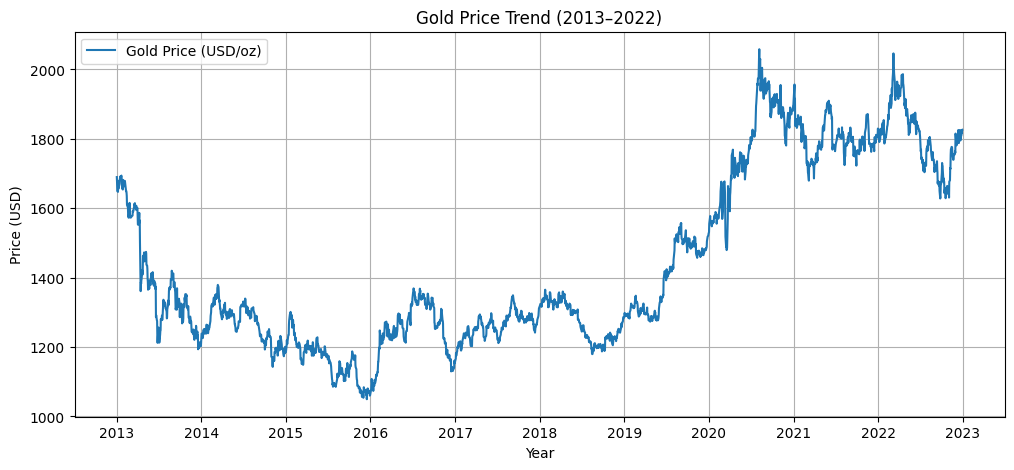

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df.index, df['Price'], label='Gold Price (USD/oz)')
plt.title('Gold Price Trend (2013–2022)')
plt.xlabel('Year')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.legend()
plt.show()


## Compute & Plot Daily Returns

In [17]:
df['Return'] = df['Price'].pct_change() * 100    # percent change
df['LogReturn'] = np.log(df['Price'] / df['Price'].shift(1))

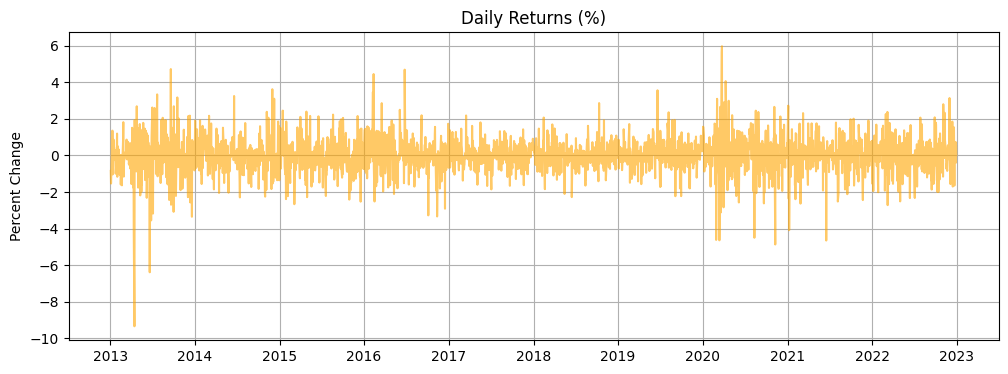

count    2582.000000
mean        0.007773
std         0.975323
min        -9.344612
25%        -0.438637
50%         0.013173
75%         0.490105
max         5.973761
Name: Return, dtype: float64


In [18]:
plt.figure(figsize=(12,4))
plt.plot(df.index, df['Return'], color='orange', alpha=0.6)
plt.title('Daily Returns (%)')
plt.ylabel('Percent Change')
plt.grid(True)
plt.show()

print(df['Return'].describe())


## Correlation Check

In [19]:
corr = df[['Price','Open','High','Low','Vol.','Change %']].corr()
print(corr)


             Price      Open      High       Low      Vol.  Change %
Price     1.000000  0.998600  0.999287  0.999396  0.016124  0.032658
Open      0.998600  1.000000  0.999327  0.999094  0.015555 -0.014479
High      0.999287  0.999327  1.000000  0.998827  0.019573  0.009196
Low       0.999396  0.999094  0.998827  1.000000  0.012298  0.013230
Vol.      0.016124  0.015555  0.019573  0.012298  1.000000 -0.002928
Change %  0.032658 -0.014479  0.009196  0.013230 -0.002928  1.000000


## Rolling Averages & Volatility

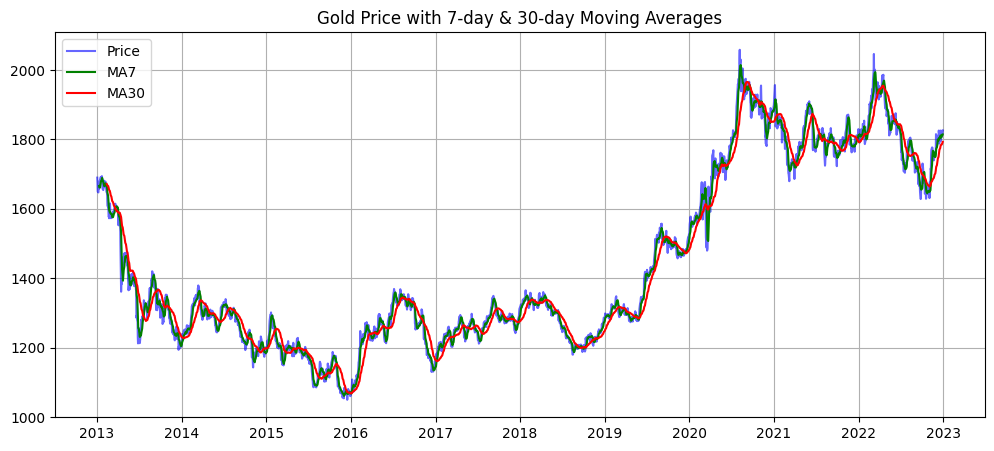

In [20]:
df['MA7'] = df['Price'].rolling(7).mean()
df['MA30'] = df['Price'].rolling(30).mean()
df['Volatility7'] = df['Return'].rolling(7).std()

plt.figure(figsize=(12,5))
plt.plot(df['Price'], label='Price', color='blue', alpha=0.6)
plt.plot(df['MA7'], label='MA7', color='green')
plt.plot(df['MA30'], label='MA30', color='red')
plt.title('Gold Price with 7-day & 30-day Moving Averages')
plt.legend()
plt.grid(True)
plt.show()


## All Models

In [21]:
df = df.copy()

df['Return'] = df['Price'].pct_change()
df['MA7'] = df['Price'].rolling(7).mean()
df['MA30'] = df['Price'].rolling(30).mean()
df['Volatility7'] = df['Return'].rolling(7).std()
df['Range'] = df['High'] - df['Low']
df['Target'] = df['Price'].shift(-1)

df = df.dropna()

features = ['Price', 'Return', 'MA7', 'MA30', 'Volatility7', 'Range']

X = df[features]
y = df['Target']

# TRAIN / TEST FOR CLASSIC ML (TIME-BASED)
split_ml = int(len(df) * 0.8)

X_train_ml = X.iloc[:split_ml]
X_test_ml  = X.iloc[split_ml:]
y_train_ml = y.iloc[:split_ml]
y_test_ml  = y.iloc[split_ml:]

scaler_ml = RobustScaler()
X_train_ml_scaled = scaler_ml.fit_transform(X_train_ml)
X_test_ml_scaled  = scaler_ml.transform(X_test_ml)

## Plots For Each Model

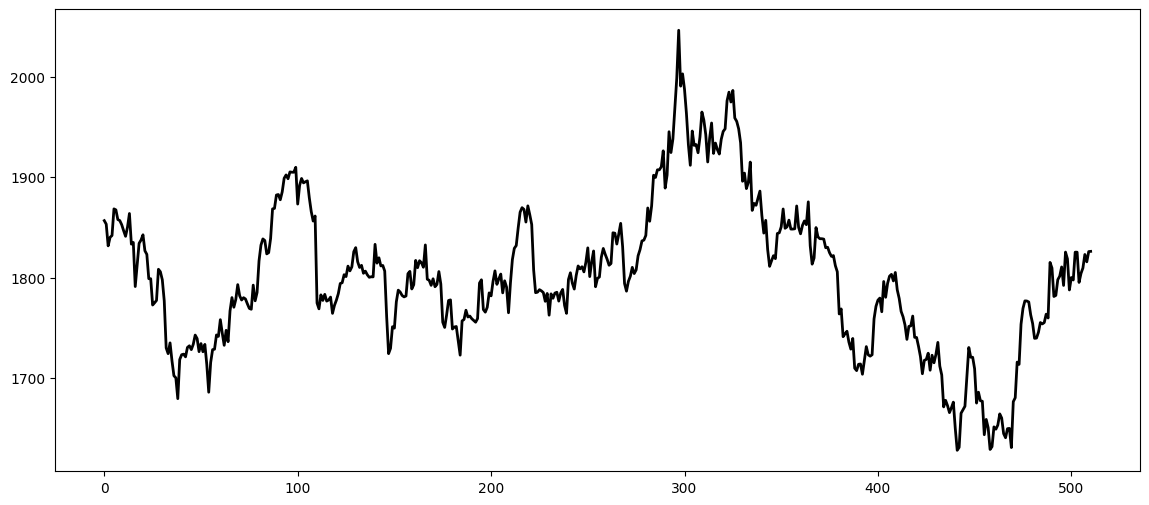

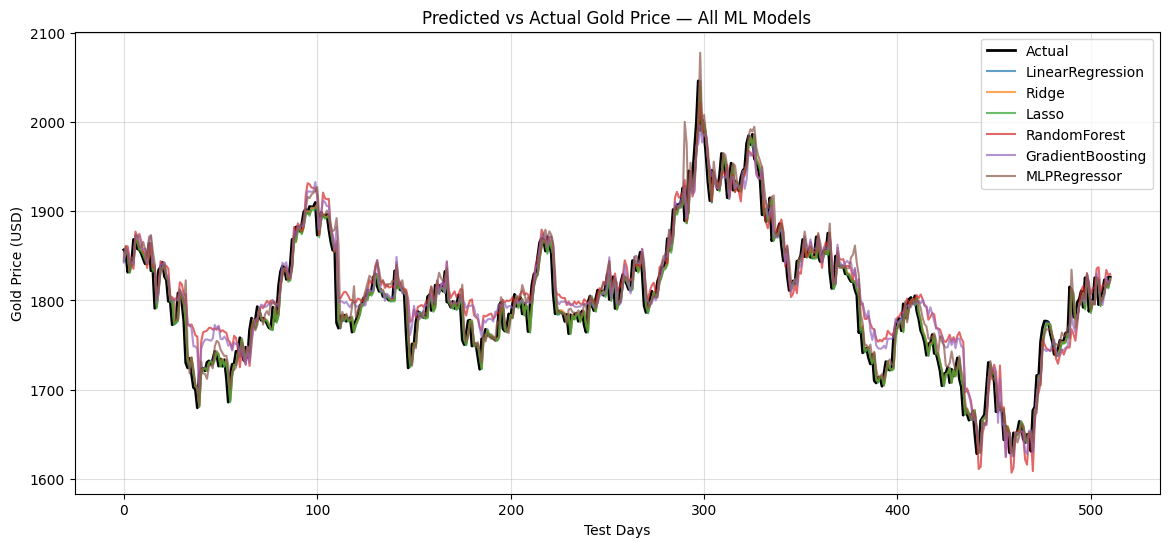

In [22]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'MLPRegressor': MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42)
}

plt.figure(figsize=(14,6))
plt.plot(y_test_ml.values, label='Actual', color='black', linewidth=2)

results = []

plt.figure(figsize=(14,6))
plt.plot(y_test_ml.values, label='Actual', color='black', linewidth=2)

for name, model in models.items():
    model.fit(X_train_ml_scaled, y_train_ml)
    preds = model.predict(X_test_ml_scaled)

    plt.plot(preds, label=name, alpha=0.7)

    r2 = r2_score(y_test_ml, preds)
    mae = mean_absolute_error(y_test_ml, preds)
    rmse = np.sqrt(mean_squared_error(y_test_ml, preds))
    results.append([name, r2, mae, rmse])

plt.title('Predicted vs Actual Gold Price — All ML Models')
plt.xlabel('Test Days')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## LSTM / Recurrent NN

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 28: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 39: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 44: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 54: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 59: ReduceLROnPlateau reducing learning rate to 1e-06.
Epoch 63: early stopping
Restoring model weights from the end of the best epoch: 53.
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
LSTM (fixed) -> R²: 0.8194, MAE: 24.33, RMSE: 31.14


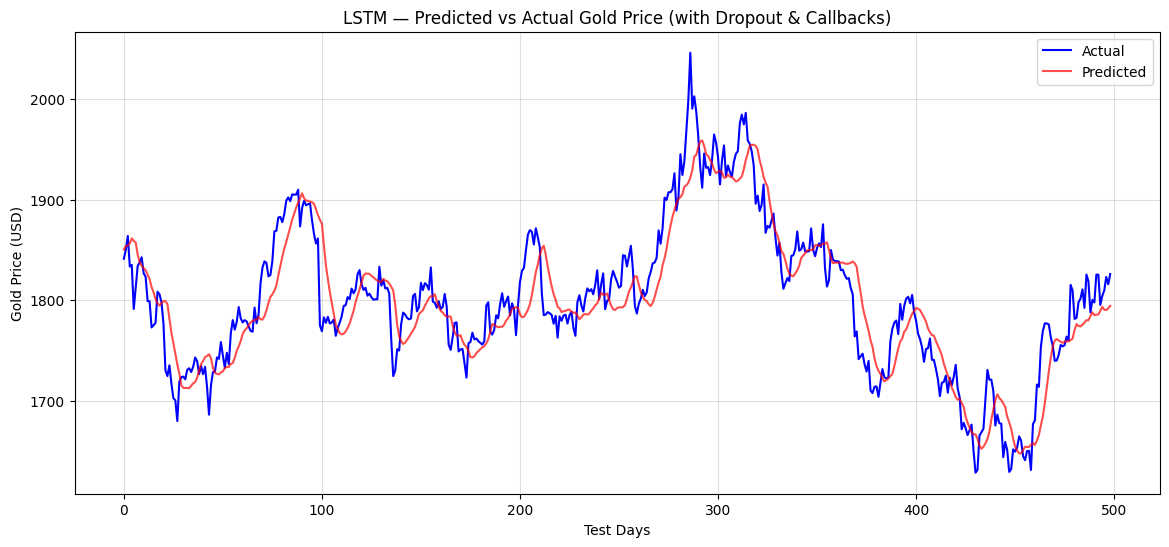

In [29]:
df_feat = df.copy()

df_feat['Return'] = df_feat['Price'].pct_change()
df_feat['MA7'] = df_feat['Price'].rolling(7).mean()
df_feat['MA30'] = df_feat['Price'].rolling(30).mean()
df_feat['Volatility7'] = df_feat['Return'].rolling(7).std()
df_feat['Range'] = df_feat['High'] - df_feat['Low']
df_feat['Target'] = df_feat['Price'].shift(-1)
df_feat = df_feat.dropna()

features = ['Price', 'Return', 'MA7', 'MA30', 'Volatility7', 'Range']

#  Prepare arrays
data_X = df_feat[features].values
data_y = df_feat['Target'].values

# Scale both X and y
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
data_X_scaled = scaler_X.fit_transform(data_X)
data_y_scaled = scaler_y.fit_transform(data_y.reshape(-1, 1))

# Build time sequences
window = 30
def make_sequences(X, y, win):
    Xs, ys = [], []
    for i in range(win, len(X)):
        Xs.append(X[i-win:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(data_X_scaled, data_y_scaled, window)

# Split 80/20
split_lstm = int(len(X_seq) * 0.8)
X_train_lstm, X_test_lstm = X_seq[:split_lstm], X_seq[split_lstm:]
y_train_lstm, y_test_lstm = y_seq[:split_lstm], y_seq[split_lstm:]

# Build LSTM model
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)


history = model_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=80,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

#  Predict & inverse transform
y_pred_scaled = model_lstm.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled).reshape(-1)
y_true = scaler_y.inverse_transform(y_test_lstm).reshape(-1)



In [ ]:
# Metrics
r2_lstm = r2_score(y_true, y_pred)
mae_lstm = mean_absolute_error(y_true, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"LSTM (fixed) -> R²: {r2_lstm:.4f}, MAE: {mae_lstm:.2f}, RMSE: {rmse_lstm:.2f}")

## Plot LSTM

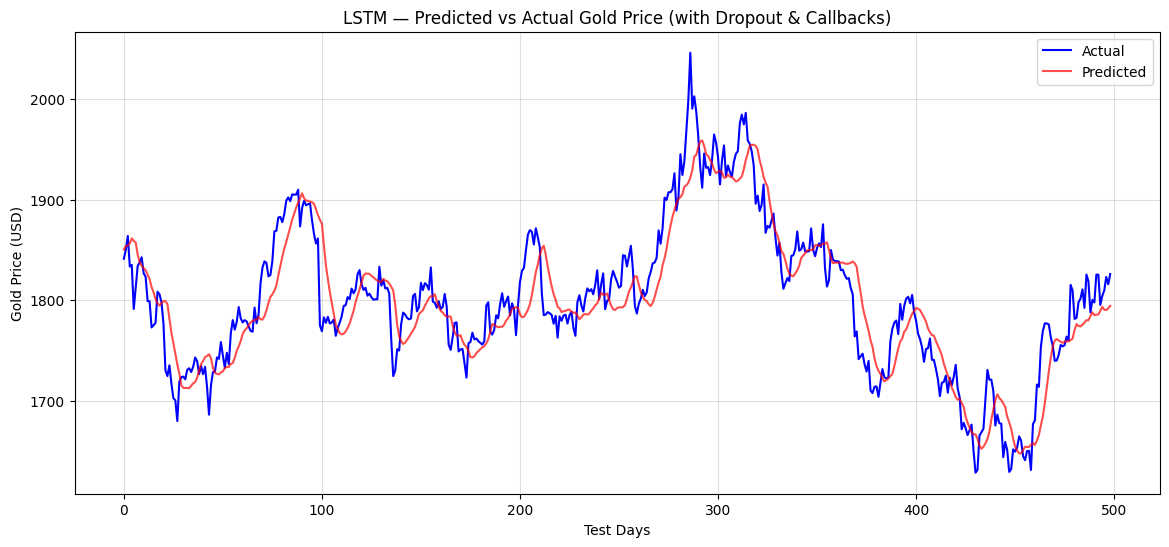

In [32]:
plt.figure(figsize=(14,6))
plt.plot(y_true, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red', alpha=0.7)
plt.title('LSTM — Predicted vs Actual Gold Price (with Dropout & Callbacks)')
plt.xlabel('Test Days')
plt.ylabel('Gold Price (USD)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## Overfitting Check

<function matplotlib.pyplot.show(close=None, block=None)>

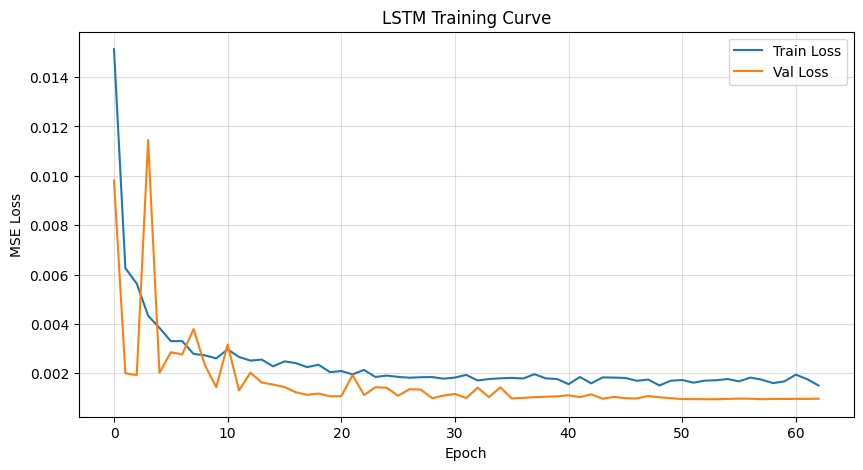

In [35]:
import matplotlib.pyplot as plt

loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])

plt.figure(figsize=(10,5))
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('LSTM Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show

## Scoreboard

Final Model Comparison:

              Model        R²        MAE       RMSE
0             Lasso  0.947482  12.289339  16.693285
1  LinearRegression  0.947463  12.154451  16.696317
2             Ridge  0.947437  12.138386  16.700484
3      MLPRegressor  0.913974  15.170321  21.364959
4  GradientBoosting  0.895442  18.133013  23.554093
5      RandomForest  0.875011  20.281022  25.752739
6              LSTM  0.819409  24.330791  31.143009


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


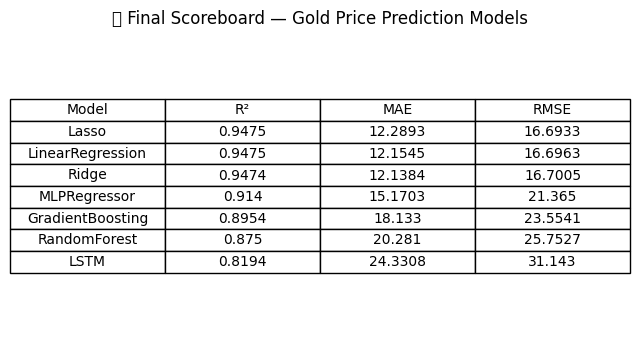

In [33]:
results.append(['LSTM', r2_lstm, mae_lstm, rmse_lstm])

# Convert to DataFrame and sort
results_df = pd.DataFrame(results, columns=['Model', 'R²', 'MAE', 'RMSE'])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)

# Display table
print("Final Model Comparison:\n")
print(results_df)

# Optional: nice visual table
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(
    cellText=results_df.round(4).values,
    colLabels=results_df.columns,
    loc='center',
    cellLoc='center'
)
table.scale(1, 1.3)
plt.title('📊 Final Scoreboard — Gold Price Prediction Models')
plt.show()

##Conclusion

This project analyzed ten years of gold price data (2013–2022) to understand long-term behavior, volatility, and predictive modeling performance.  
After data cleaning, exploratory analysis, and feature engineering (returns, moving averages, volatility, and range), several machine learning and neural network models were trained and compared.

Linear models (Linear Regression, Ridge, and Lasso) achieved the highest accuracy with R² ≈ 0.947, MAE ≈ 12, and RMSE ≈ 16.7, indicating that gold prices follow mostly linear temporal relationships with smooth trends.  
Non-linear models such as Random Forest and Gradient Boosting performed slightly lower, and the MLP Regressor captured some non-linear patterns but did not exceed linear baselines.  
The LSTM network achieved R² ≈ 0.82, showing it can learn temporal dependencies but requires more tuning and richer time-series features to outperform simpler models.

The analysis shows that for financial time series like gold prices, classical regression with engineered features remains highly competitive. Neural networks such as LSTM become more useful when additional lag features, longer windows, or multiple correlated financial indicators are included.

